In [1]:
# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Importación de Archivo CSV (Comma-Separated Values)

datos_csv = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Semana 4\usuarios_win_mac_lin.csv", encoding= "ISO-8859-1")
print("Archivo CSV")
datos_csv.head()

Archivo CSV


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [5]:
# Armado del modelo

# Separamos la variable objetivo
y_datos_usuarios = datos_csv["clase"]
x_datos_usuarios = datos_csv.drop("clase", axis=1)

# Dividimos en datos de entrenamiento y prueba
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(x_datos_usuarios, y_datos_usuarios, test_size=0.3, random_state=42)

# Modelo de regresión logística multinomial
# multi_class="multinomial" especifica que es un problema con más de dos clases
# solver="lbfgs" es el algoritmo de optimización recomendado
log_reg_multi = LogisticRegression(max_iter=1000, solver="lbfgs")
# El parámtro multi_class fue marcado como obsoleto (deprecated) en la versión 1.5 y se eliminará en la 1.8.
# el solver trabajará con enfoque multinomial cuando corresponda
log_reg_multi.fit(X_train_v, y_train_v)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


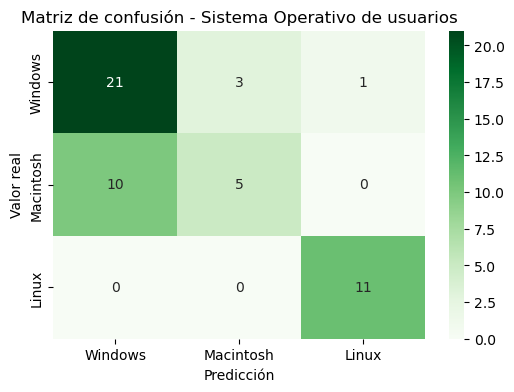


  Reporte de Métricas

              precision    recall  f1-score   support

     Windows       0.68      0.84      0.75        25
   Macintosh       0.62      0.33      0.43        15
       Linux       0.92      1.00      0.96        11

    accuracy                           0.73        51
   macro avg       0.74      0.72      0.71        51
weighted avg       0.71      0.73      0.70        51



In [12]:
# Realizar la predicción, armar matriz de confusión y reporte de métricas

# Predicciones
y_pred_usuarios = log_reg_multi.predict(X_test_v)

# Matriz de confusión
cm_usuarios = confusion_matrix(y_test_v, y_pred_usuarios)
plt.figure(figsize=(6,4))
sns.heatmap(cm_usuarios, annot=True, fmt="d", cmap="Greens", xticklabels=["Windows", "Macintosh", "Linux"], yticklabels=["Windows", "Macintosh", "Linux"])
plt.title("Matriz de confusión - Sistema Operativo de usuarios")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
print()
plt.show()

# Reporte de métricas
print("\n \033[1m Reporte de Métricas\033[0m\n")
print(classification_report(y_test_v, y_pred_usuarios,target_names=["Windows", "Macintosh", "Linux"]))

